### **Naive Bayes: Mathematical Core and Implementation Insights**

Naive Bayes (NB) is a probabilistic classifier rooted in **Bayes' Theorem** with an assumption of feature independence. Despite its simplicity, it performs exceptionally well in high-dimensional spaces like text classification.

---

#### **Core Mathematical Concepts**

1. **Bayes' Theorem**:
   $$
   P(Y|X) = \frac{P(X|Y) \cdot P(Y)}{P(X)}
   $$
   - **Goal**: Maximize $ P(Y|X) $ (posterior probability) for class $ Y $ given features $ X $.
   - **Simplification**: Since $ P(X) $ is constant for all classes, focus on maximizing the numerator: $ P(X|Y) \cdot P(Y) $.

2. **Feature Independence Assumption**:
   $$
   P(X|Y) = \prod_{i=1}^{n} P(x_i|Y)
   $$
   - Assumes features $ x_1, x_2, ..., x_n $ are conditionally independent given $ Y $.

3. **Prior Probability**:
   $$
   P(Y=c) = \frac{\text{Number of samples in class } c}{\text{Total samples}}
   $$

4. **Likelihood Estimation**:
   - **Categorical Features**: Frequency counts.
     $$
     P(x_i|Y=c) = \frac{\text{Count}(x_i, Y=c)}{\text{Count}(Y=c)}
     $$
   - **Continuous Features (Gaussian NB)**: Assume normal distribution.
     $$
     P(x_i|Y=c) = \frac{1}{\sqrt{2\pi\sigma_c^2}} \exp\left(-\frac{(x_i - \mu_c)^2}{2\sigma_c^2}\right)
     $$
   - **Smoothing (Laplace Correction)**: Avoids zero probabilities.
     $$
     P(x_i|Y=c) = \frac{\text{Count}(x_i, Y=c) + \alpha}{\text{Count}(Y=c) + \alpha \cdot k}
     $$
     where $ \alpha $ is the smoothing parameter and $ k $ is the number of feature values.

5. **Log-Probability for Stability**:
   $$
   \log P(Y|X) \propto \log P(Y) + \sum_{i=1}^{n} \log P(x_i|Y)
   $$
   Prevents underflow from multiplying small probabilities.

---

#### **Manual Example: Categorical Features**

**Dataset**:
| Outlook | Temp | Play |
|---------|------|------|
| Sunny   | Hot  | No   |
| Sunny   | Hot  | No   |
| Rainy   | Cold | Yes  |
| Rainy   | Hot  | Yes  |
| Sunny   | Cold | Yes  |
| Rainy   | Cold | No   |

**Step 1: Compute Priors**:
- $ P(\text{Yes}) = 3/6 = 0.5 $
- $ P(\text{No}) = 3/6 = 0.5 $

**Step 2: Compute Likelihoods** (with Laplace smoothing $ \alpha=1 $):
- **Outlook**:
  - $ P(\text{Sunny}|\text{Yes}) = \frac{1+1}{3+2} = 2/5 $
  - $ P(\text{Sunny}|\text{No}) = \frac{2+1}{3+2} = 3/5 $
- **Temp**:
  - $ P(\text{Cold}|\text{Yes}) = \frac{2+1}{3+2} = 3/5 $
  - $ P(\text{Cold}|\text{No}) = \frac{1+1}{3+2} = 2/5 $

**Step 3: Predict New Sample (Outlook=Sunny, Temp=Cold)**:
- **Yes**:
  $$
  \log(0.5) + \log(2/5) + \log(3/5) \approx -0.693 + (-0.916) + (-0.511) = -2.119
  $$
- **No**:
  $$
  \log(0.5) + \log(3/5) + \log(2/5) \approx -0.693 + (-0.511) + (-0.916) = -2.119
  $$
- **Result**: Tie; default to majority class or use tie-breaking logic.

---

#### **Manual Example: Gaussian NB**

**Dataset**:
- Class 0: [1, 2, 3]
- Class 1: [4, 5, 6]

**Step 1: Compute Parameters**:
- $ \mu_0 = 2, \sigma_0^2 = 1 $
- $ \mu_1 = 5, \sigma_1^2 = 1 $

**Step 2: Predict X=3**:
- **Class 0**:
  $$
  \log(0.5) + \log\left(\frac{1}{\sqrt{2\pi}} e^{-0.5}\right) \approx -0.693 + (-1.419) = -2.112
  $$
- **Class 1**:
  $$
  \log(0.5) + \log\left(\frac{1}{\sqrt{2\pi}} e^{-2}\right) \approx -0.693 + (-2.922) = -3.615
  $$
- **Result**: Predict Class 0 (closer to mean 2).

---

#### **Implementation Insights**

1. **GaussianNB**:
   ```python
   from sklearn.naive_bayes import GaussianNB
   model = GaussianNB()
   model.fit(X_train, y_train)
   model.predict(X_test)
   ```
   - **Internals**: Computes $ \mu $ and $ \sigma $ for each feature/class. Uses log-likelihoods for stability.

2. **MultinomialNB**:
   ```python
   from sklearn.naive_bayes import MultinomialNB
   model = MultinomialNB(alpha=1.0)
   model.fit(X_train_counts, y_train)
   ```
   - **Internals**: Applies Laplace smoothing. Uses term frequencies for $ P(x_i|Y) $.

3. **Handling Numerical Stability**:
   - Replace multiplication with summation in log space.
   - Use `numpy.log` and `scipy.stats.norm.logpdf` for Gaussian features.

---

#### **Key Considerations**

- **Independence Assumption**: Violated in real-world data but often works well in practice.
- **Smoothing**: Critical for sparse data (e.g., text classification).
- **Feature Type Matching**: Use Gaussian for continuous, Multinomial/Bernoulli for discrete/binary features.



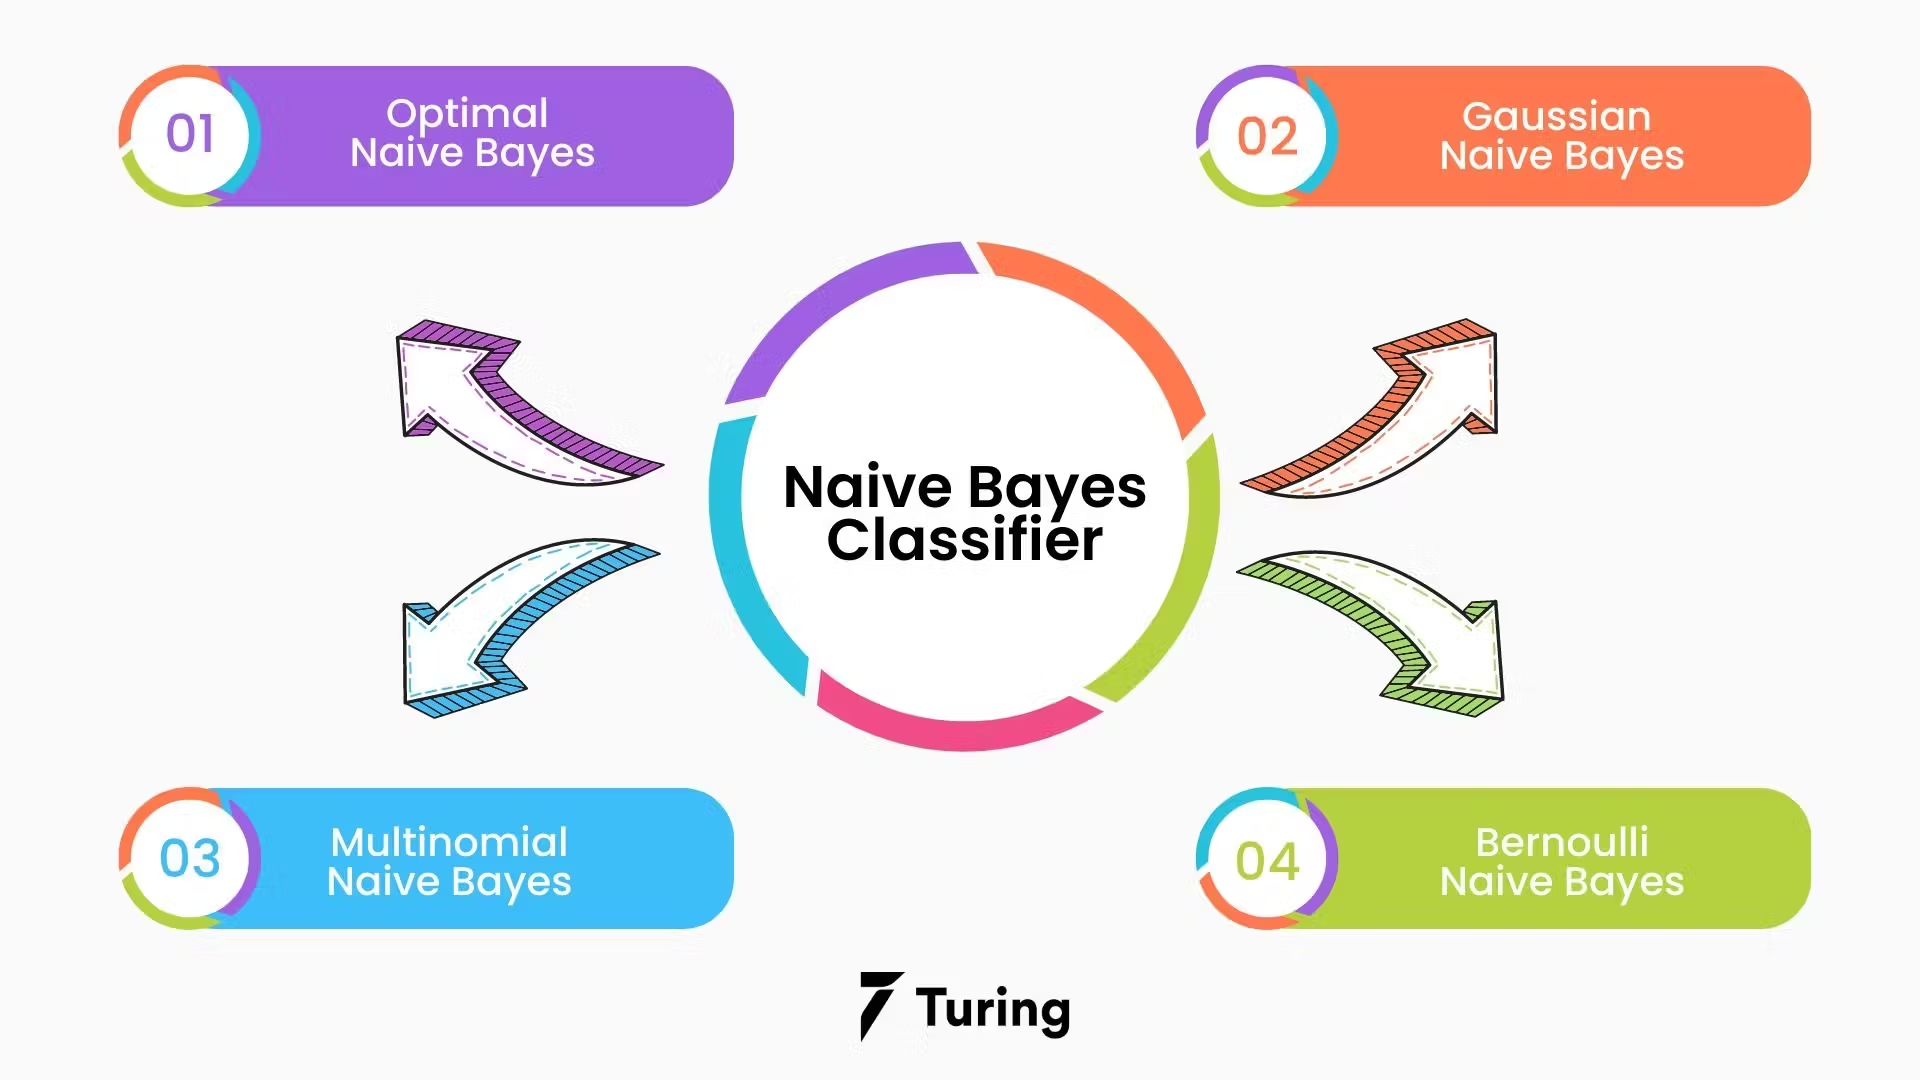

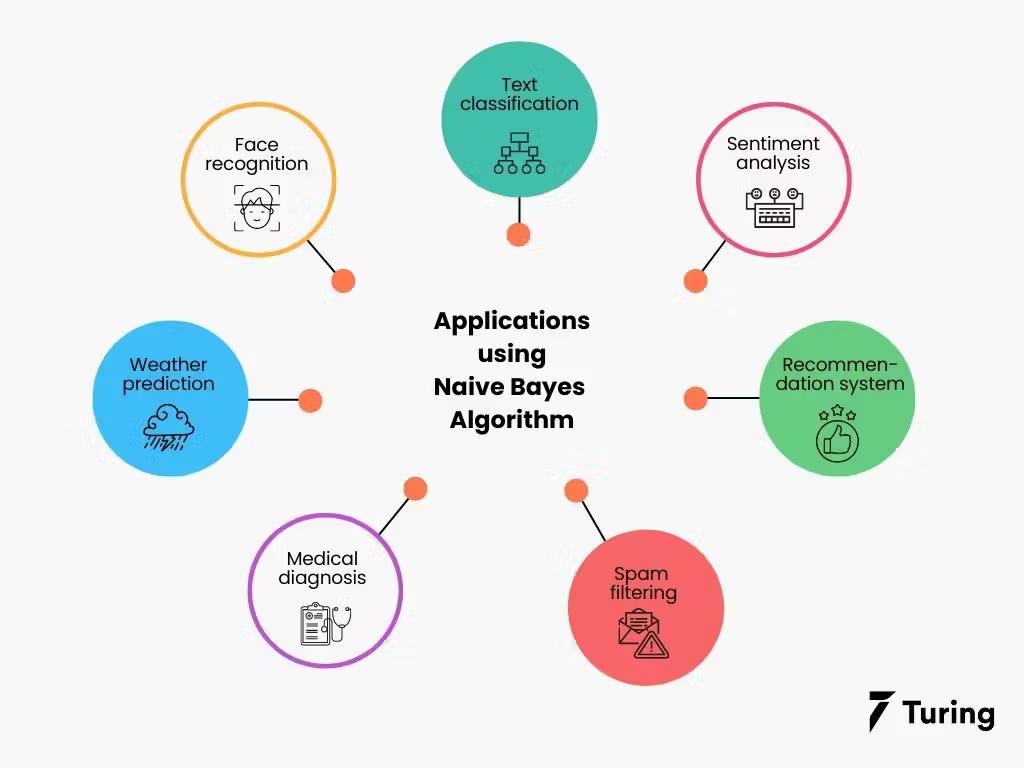

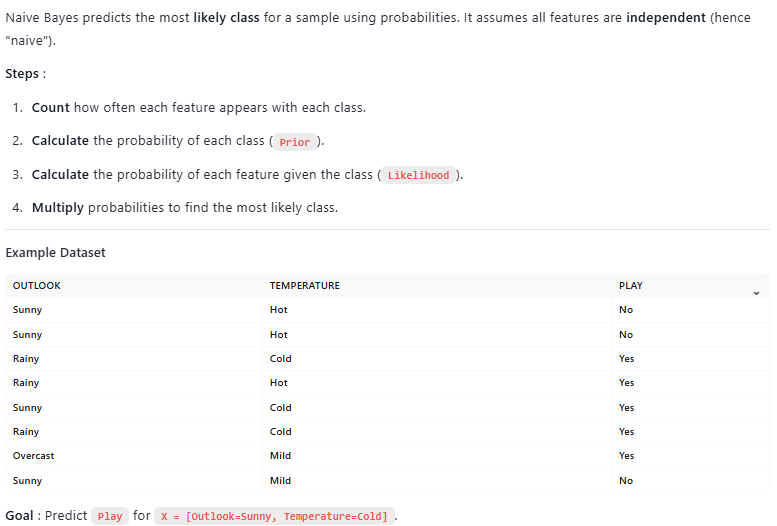

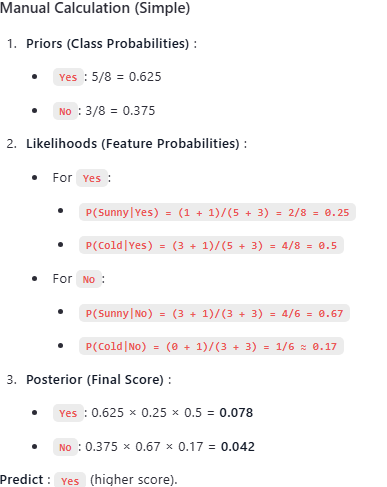

##Code Implement

In [4]:
X_train = [["Sunny", "Hot"], ["Sunny", "Hot"], ["Rainy", "Cold"], ["Rainy", "Hot"],
           ["Sunny", "Cold"], ["Rainy", "Cold"], ["Overcast", "Mild"], ["Sunny", "Mild"]]
y_train = ["No", "No", "Yes", "Yes", "Yes", "Yes", "Yes", "No"]

In [10]:
# Training data
X_train = [["Sunny", "Hot"], ["Sunny", "Hot"], ["Rainy", "Cold"], ["Rainy", "Hot"],
           ["Sunny", "Cold"], ["Rainy", "Cold"], ["Overcast", "Mild"], ["Sunny", "Mild"]]
y_train = ["No", "No", "Yes", "Yes", "Yes", "Yes", "Yes", "No"]

# Count frequencies
from collections import defaultdict

# Dictionary to store counts: (class, feature_index, feature_value) -> count
counts = defaultdict(int)
class_counts = defaultdict(int)

for features, label in zip(X_train, y_train):
    class_counts[label] += 1
    for i, value in enumerate(features):
        counts[(label, i, value)] += 1

# Predict function
def predict(sample):
    best_class, best_score = None, -1
    for label in class_counts:
        # Prior probability: P(class)
        score = class_counts[label]
        for i, value in enumerate(sample):
            # Likelihood: P(feature=value | class=label)
            score *= counts[(label, i, value)] / class_counts[label]
        if score > best_score:
            best_score, best_class = score, label
    return best_class

# Test prediction
print(predict(["Sunny", "Cold"]))  # Output: Yes

Yes




---

## ✅ How Naive Bayes Works on Numerical Data

With **numerical features**, Naive Bayes assumes that the values for each feature in a class follow a **normal (Gaussian) distribution**.

So instead of counting how often a value appears, we calculate:

> **P(xᵢ | Y = c)** using the **probability density function** of a normal distribution.

---

## 📈 Gaussian Naive Bayes Formula

For a feature $ x_i $ and class $ c $:

$$
P(x_i \mid Y = c) = \frac{1}{\sqrt{2\pi\sigma_c^2}} \cdot e^{-\frac{(x_i - \mu_c)^2}{2\sigma_c^2}}
$$

Where:
- $ \mu_c $: mean of feature $ x_i $ in class $ c $
- $ \sigma_c $: standard deviation of feature $ x_i $ in class $ c $

We do this for **each feature** and **each class**, then multiply all probabilities together (with prior), and pick the highest one.

---

## 🧮 Example with Numerical Data

Let’s use a simple dataset:

| Height (cm) | Weight (kg) | Gender |
|-------------|-------------|--------|
| 170         | 65          | Male   |
| 175         | 70          | Male   |
| 160         | 55          | Female |
| 165         | 50          | Female |

### Step 1: Compute Mean and Std for Each Class

| Class  | Height Mean | Height Std | Weight Mean | Weight Std |
|--------|-------------|------------|-------------|------------|
| Male   | 172.5       | 3.54       | 67.5        | 3.54       |
| Female | 162.5       | 3.54       | 52.5        | 3.54       |

### Step 2: Predict New Sample

Predict gender for `[Height=172, Weight=68]`

#### For Male:
- P(Height=172 | Male): Use normal PDF at 172 with μ=172.5, σ=3.54
- P(Weight=68 | Male): Use normal PDF at 68 with μ=67.5, σ=3.54

#### For Female:
- P(Height=172 | Female): Very low (far from 162.5)
- P(Weight=68 | Female): Also very low

Multiply these with prior probability of each class and choose the higher result.

---

## 🔧 Minimal Code for Gaussian Naive Bayes

Here's a **simple implementation** using only NumPy:

```python
import numpy as np

# Sample training data
X_train = np.array([
    [170, 65],
    [175, 70],
    [160, 55],
    [165, 50]
])
y_train = np.array(["Male", "Male", "Female", "Female"])

# Group data by class
class_stats = {}

for cls in np.unique(y_train):
    X_cls = X_train[y_train == cls]
    mean = X_cls.mean(axis=0)
    std = X_cls.std(axis=0)
    class_stats[cls] = {"mean": mean, "std": std}

# Probability density function for normal distribution
def gaussian_pdf(x, mean, std):
    exponent = np.exp(-((x - mean) ** 2) / (2 * std ** 2))
    return (1 / (np.sqrt(2 * np.pi) * std)) * exponent

# Prediction function
def predict_gnb(sample):
    best_class, best_prob = None, -1
    for cls, stats in class_stats.items():
        mean = stats["mean"]
        std = stats["std"]
        
        # Prior probability
        prior = np.mean(y_train == cls)

        # Likelihoods (log to avoid underflow)
        log_likelihood = np.sum(np.log(gaussian_pdf(sample, mean, std)))

        total_prob = np.log(prior) + log_likelihood

        if total_prob > best_prob:
            best_prob = total_prob
            best_class = cls
    return best_class

# Test prediction
sample = np.array([172, 68])
print(predict_gnb(sample))  # Output: 'Male'
```

---

## 🔍 Key Notes

| Feature Type     | Suitable NB Variant       |
|------------------|---------------------------|
| Categorical      | MultinomialNB / BernoulliNB |
| Binary           | BernoulliNB               |
| Continuous       | GaussianNB ✅              |
| Word Frequencies | MultinomialNB              |

---

## ✅ Summary

- For **numerical data**, Naive Bayes uses **Gaussian distribution**.
- You calculate **mean** and **standard deviation** per feature per class.
- Then compute likelihood using the **PDF**.
- Multiply with prior and choose class with highest score.

This is called **Gaussian Naive Bayes**, and it's great for small datasets or when you need fast predictions!



In [11]:
import numpy as np

# Sample training data
X_train = np.array([
    [170, 65],
    [175, 70],
    [160, 55],
    [165, 50]
])
y_train = np.array(["Male", "Male", "Female", "Female"])

# Group data by class
class_stats = {}

for cls in np.unique(y_train):
    X_cls = X_train[y_train == cls]
    mean = X_cls.mean(axis=0)
    std = X_cls.std(axis=0)
    class_stats[cls] = {"mean": mean, "std": std}

# Probability density function for normal distribution
def gaussian_pdf(x, mean, std):
    exponent = np.exp(-((x - mean) ** 2) / (2 * std ** 2))
    return (1 / (np.sqrt(2 * np.pi) * std)) * exponent

# Prediction function
def predict_gnb(sample):
    best_class, best_prob = None, -1
    for cls, stats in class_stats.items():
        mean = stats["mean"]
        std = stats["std"]

        # Prior probability
        prior = np.mean(y_train == cls)

        # Likelihoods (log to avoid underflow)
        log_likelihood = np.sum(np.log(gaussian_pdf(sample, mean, std)))

        total_prob = np.log(prior) + log_likelihood

        if total_prob > best_prob:
            best_prob = total_prob
            best_class = cls
    return best_class

# Test prediction
sample = np.array([172, 68])
print(predict_gnb(sample))  # Output: 'Male'

None




---

### 🧠 1. **What is Naive Bayes?**
- A probabilistic classifier based on **Bayes’ Theorem**.
- Assumes **features are independent** (the "naive" part).
- Used for classification tasks like spam detection, sentiment analysis.

---

### 📐 2. **What is Bayes’ Theorem?**
$$
P(Y|X) = \frac{P(X|Y) \cdot P(Y)}{P(X)}
$$
- **P(Y|X)**: Posterior probability (what we want to find)
- **P(X|Y)**: Likelihood
- **P(Y)**: Prior
- **P(X)**: Evidence (constant for all classes)

---

### 🤔 3. **Why is it called “Naive”?**
Because it assumes **all features are independent**, which is rarely true in real life. But still works well in practice.

---

### 🛠️ 4. **What are the different types of Naive Bayes models?**

| Model             | Use Case                         |
|------------------|----------------------------------|
| **GaussianNB**   | Continuous data (e.g., height, weight) |
| **MultinomialNB**| Discrete counts (e.g., word counts in text) |
| **BernoulliNB**  | Binary features (e.g., presence/absence of a word) |

---

### ⚖️ 5. **When to use which type of Naive Bayes?**
- **Gaussian**: For continuous numerical features.
- **Multinomial**: For text classification with word frequencies.
- **Bernoulli**: For binary features (yes/no, present/absent).

---

### 🧪 6. **How does Naive Bayes handle zero probabilities?**
Using **Laplace Smoothing**:
$$
P(x_i|Y=c) = \frac{\text{count}(x_i, Y=c) + \alpha}{\text{count}(Y=c) + \alpha \cdot k}
$$
- $ \alpha = 1 $ usually
- $ k $: number of possible values per feature

---

### 🧮 7. **How is likelihood calculated in GaussianNB?**
Assumes normal distribution:
$$
P(x_i|Y=c) = \frac{1}{\sqrt{2\pi\sigma_c^2}} \cdot e^{-\frac{(x_i - \mu_c)^2}{2\sigma_c^2}}
$$
Where:
- $ \mu_c $: mean of feature in class c
- $ \sigma_c $: standard deviation

---

### 🧩 8. **Pros and Cons of Naive Bayes**

| Pros ✅                          | Cons ❌                      |
|----------------------------------|------------------------------|
| Fast and simple                  | Features independence assumption is often wrong |
| Works well with high-dim data    | Sensitive to input data quality |
| Good for text classification     | Zero frequency problem if not smoothed |

---

### 🎯 9. **Is Naive Bayes a linear classifier?**
- **Not exactly**, but under certain assumptions (like Gaussian), it behaves like one.

---

### 🧑‍💻 10. **Sample code for Naive Bayes using scikit-learn**

```python
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
```

Also available:
```python
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
```

---

### 🔁 11. **Can Naive Bayes be used for regression?**
No. It's a **classification algorithm** only.

---

### 🧬 Bonus: Related Concepts to Know

| Concept           | Minimal Explanation |
|-------------------|---------------------|
| **Log Loss**      | Measures error in predicted probabilities |
| **Confusion Matrix** | Shows TP, TN, FP, FN |
| **Precision / Recall / F1** | Metrics for imbalanced classification |
| **Smoothing**     | Avoids zero probabilities |
| **Feature Scaling** | Not needed for NB (uses probabilities) |
| **Overfitting**   | Rarely overfits due to simplicity |
| **Bias-Variance Tradeoff** | High bias, low variance |

---



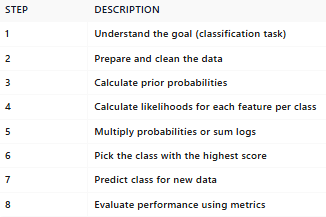